# Get started with Earth Engine for Python

This quickstart will give you an interactive introduction to visualizing and
analyzing geospatial data with the Earth Engine Python interface.

## Before you begin

[Register or create](https://code.earthengine.google.com/register) a Google Cloud Project; you'll be prompted to complete the following steps. If you already have a project registered for Earth Engine access, skip to the next section.

  * Select noncommercial.
  * Project type: 
  * Create a new Google Cloud project or select an existing project.
  * Confirm your project information.  




## Notebook setup

**1.** Import the Earth Engine and geemap libraries.

In [1]:
import ee
import geemap.core as geemap

**2.** Authenticate and initialize the Earth Engine service. Follow the
resulting prompts to complete authentication. Be sure to replace PROJECT_ID
with the name of the project you set up for this quickstart.

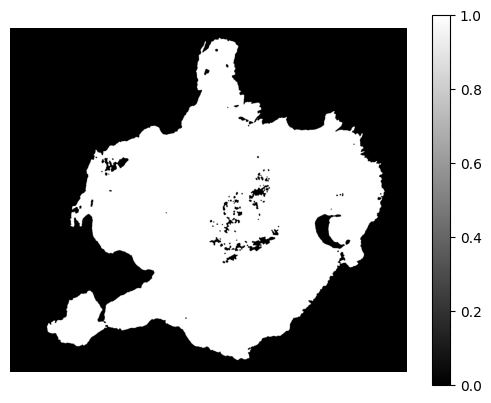

In [16]:
import rasterio
import matplotlib.pyplot as plt
with rasterio.open("/home/desy/rift-waters/dataset/naivasha/processed/sar_water_mask/naivasha_20251231.tif") as src:
    image = src.read(1)
    profile = src.profile
    transform = src.transform
    bounds = src.bounds
    plt.imshow(image, cmap='gray')
    plt.colorbar()
    plt.axis('off')
    plt.show()

In [2]:
ee.Authenticate()
ee.Initialize(project='riftwaters')


3. Select a region of interest and time range

In [3]:
##Lake baringo

# ROI = ee.Geometry.Polygon(
#             [
#                 [35.98391292157122, 0.4153611370519164],
#                 [36.16518733563372, 0.4153611370519164],
#                 [36.16518733563372, 0.7446867187538047],
#                 [35.98391292157122, 0.7446867187538047],
#             ]
#         )
##Look for another region most probably a ward
roi = ee.Geometry.Polygon([
            [35.790877429240396,2.2570223825044393],
            [36.752181140177896,2.2570223825044393],
            [36.752181140177896,4.6037188442560275],
            [35.790877429240396,4.6037188442560275],
            [35.790877429240396,2.2570223825044393]
        ])

start_date = "2021-12-01"  ## ensure dates are in the format 'YYYY-MM-DD'
end_date = "2021-12-31"


In [3]:
dataset = ee.ImageCollection('ESA/WorldCover/v200').first()

visualization = {'bands': ['Map']}

m = geemap.Map()
m.center_object(dataset)
m.add_layer(dataset, visualization, 'Landcover')
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

4. Downloading Images from various catalogs.

If you want more information about different catalogs you can access them here https://developers.google.com/earth-engine/datasets


### Acquiring sentinel 1 image

Sentinel 1 uses Synthetic apateur radar(SAR) for imaging
Bands available for Sentinel 1 are;
- **VH:** Single co-polarization, horizontal transmit/horizontal receive

- **HV:** Dual-band cross-polarization, horizontal transmit/vertical receive

- **VV:** Single co-polarization, vertical transmit/vertical receive

- **VH:** Dual-band cross-polarization, vertical transmit/horizontal receive

All these bands best resolution is 10 meters, that is one pixel on a sentinel 1 image is 10m by 10m

In [4]:

def mask_edge(image):
  edge = image.lt(-30.0)
  masked_image = image.mask().And(edge.Not())
  return image.updateMask(masked_image).clip(roi)


img_vv = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select('VV')
    .map(mask_edge)
)

desc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).median()
asc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).median()




m = geemap.Map()
m.set_center(36., 0.6, 12)
#m.add_layer(asc, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
m.add_layer(desc, {'min': -25, 'max': 5}, 'Multi-T Mean DESC', True)
m

Map(center=[0.6, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

### Downloading Sentinel 2 image
Sentinel 2 uses a multispectral sensor for visible and near infrared light reflected from the surface of the earth.
S2 bands include;
- 

In [5]:
# Load Sentinel-2 image collection
def mask_s2_clouds(image):
    qa = image.select("QA60")
    cloud_mask = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    return image.updateMask(cloud_mask).divide(10000)

s2_image = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(roi.geometry())
    .filterDate(start_date, end_date)
    .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", 20))
)
count = s2_image.size().getInfo()
print(f"Found {count} Sentinel-2 images")




s2_image = s2_image.map(mask_s2_clouds)
s2_image = s2_image.median().clip(roi)


visualization = {
    "min": 0.0,
    "max": 0.3,
    "bands": ["B4", "B3", "B2"],
}

m = geemap.Map()
m.set_center(36., 0.6, 10)
m.add_layer(s2_image, visualization, "RGB")
m

Found 5 Sentinel-2 images


Map(center=[0.6, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [10]:
# Construct a collection of corresponding Dynamic World and Sentinel-2 for
# inspection. Filter by region and date.
START = ee.Date('2021-04-02')
END = START.advance(1, 'day')

# col_filter = ee.Filter.And(
#     ee.Filter.bounds(ee.Geometry.Point(36., 0.6, 10)),
#     ee.Filter.date(START, END),
# )

dw_col = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1').filterBounds(roi.geometry()).filterDate(start_date, end_date)

# Link DW and S2 source images.
linked_col = dw_col.linkCollection(s2_image, s2_image.bandNames())

# Get example DW image with linked S2 image.
linked_image = ee.Image(linked_col.first())

# Create a visualization that blends DW class label with probability.
# Define list pairs of DW LULC label and color.
CLASS_NAMES = [
    'water',
    'trees',
    'grass',
    'flooded_vegetation',
    'crops',
    'shrub_and_scrub',
    'built',
    'bare',
    'snow_and_ice',
]

VIS_PALETTE = [
    '419bdf',
    '397d49',
    '88b053',
    '7a87c6',
    'e49635',
    'dfc35a',
    'c4281b',
    'a59b8f',
    'b39fe1',
]

# Create an RGB image of the label (most likely class) on [0, 1].
dw_rgb = (
    linked_image.select('label')
    .visualize(min=0, max=8, palette=VIS_PALETTE)
    .divide(255)
).clip(roi)

# Get the most likely class probability.
top1_prob = linked_image.select(CLASS_NAMES).reduce(ee.Reducer.max())

# Create a hillshade of the most likely class probability on [0, 1]
top1_prob_hillshade = ee.Terrain.hillshade(top1_prob.multiply(100)).divide(255)

# Combine the RGB image with the hillshade.
dw_rgb_hillshade = dw_rgb.multiply(top1_prob_hillshade)

# Display the Dynamic World visualization with the source Sentinel-2 image.
m = geemap.Map()
m.set_center(36., 0.6, 12)
m.add_layer(
    linked_image,
    {'min': 0, 'max': 3000, 'bands': ['B4', 'B3', 'B2']},
    'Sentinel-2 L1C',
)
m.add_layer(
    dw_rgb_hillshade,
    {'min': 0, 'max': 0.65},
    'Dynamic World V1 - label hillshade',
)
m

Map(center=[0.6, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

In [28]:
dataset = ee.ImageCollection('LANDSAT/LC08/C02/T1').filterBounds(roi).filterDate(start_date, end_date).filter(ee.Filter.lte("CLOUD_COVER", 20))
            

true_color_432 = dataset.select(['B4', 'B3', 'B2'])

true_color_432_vis = {'min': 0.0, 'max': 3000}

m = geemap.Map()
m.set_center(36., 0.6, 10)
m.add_layer(true_color_432, true_color_432_vis, 'True Color (432)')
m

Map(center=[0.6, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

Saving an Image

In [35]:
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterBounds(roi).filterDate(start_date, end_date).filter(ee.Filter.lte("CLOUD_COVER", 20))
           

count = landsat.size().getInfo()
print(f"  Found {count} images")



# Apply scale factors
def scale_landsat(image):
    optical_bands = ["SR_B2", "SR_B3", "SR_B4", "SR_B5", "SR_B6", "SR_B7"]
    optical_names = ["Blue", "Green", "Red", "NIR", "SWIR1", "SWIR2"]
    thermal_bands = ["ST_B10"]
    thermal_names = ["Thermal"]

    # Scale optical bands
    for i, band in enumerate(optical_bands):
        image = image.updateMask(image.select(band).gt(0))
        scaled = image.select(band).multiply(0.0000275).add(-0.2)
        image = image.addBands(scaled.rename(optical_names[i]))

    # Scale thermal band
    for i, band in enumerate(thermal_bands):
        scaled = image.select(band).multiply(0.00341802).add(149.0)
        image = image.addBands(scaled.rename(thermal_names[i]))

    return image.select(optical_names + thermal_names)

landsat_scaled = landsat.map(scale_landsat)
composite = landsat_scaled.median().clip(roi)

visualization = {
    'bands': ['Red', 'Green', 'Blue'],
    'min': 0.0,
    'max': 0.3,
}

m = geemap.Map()
m.set_center(36., 0.6, 10)
m.add_layer(composite, visualization, 'True Color (432)')
m

  Found 0 images


Map(center=[0.6, 36.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', t…

## What's next

  * Learn about analyzing data with Earth Engine's [objects and methods](https://developers.google.com/earth-engine/guides/objects_methods_overview).
  * Learn about Earth Engine's [processing environments](https://developers.google.com/earth-engine/guides/processing_environments).
  * Learn about Earth Engine's [machine learning capabilities](https://developers.google.com/earth-engine/guides/machine-learning).
  * Learn how to [export your computation results to BigQuery](https://developers.google.com/earth-engine/guides/exporting_to_bigquery).